In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OneHotEncoder
import joblib

from sklearn.metrics import root_mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

import optuna

import time

# 1. Data Import and basic prep

In [2]:
df = pd.read_csv(r'data_model.csv')
df.head()

,Datum,PV(kWh),sin_month_x,cos_month_x,sin_dayofyear_x,cos_dayofyear_x,year_x,winddir,feelslikemin,dew,...,cos_dayofyear_y,year_y,sunset_seconds,sunrise_seconds,sunset_sin,sunset_cos,sunrise_sin,sunrise_cos,day_length_seconds,day_length_hours
0,2024-01-01,1.2,0.5,0.866025,0.017213,0.999852,2024,243.4,-1.9,1.7,...,0.999852,2024,57521,27866,-0.863139,-0.504967,0.897964,-0.440070,29655,8.237500
1,2024-01-02,1.3,0.5,0.866025,0.034422,0.999407,2024,202.9,-3.2,0.2,...,0.999407,2024,57581,27863,-0.865334,-0.501196,0.898060,-0.439874,29718,8.255000
2,2024-01-03,1.9,0.5,0.866025,0.051620,0.998667,2024,221.7,-0.7,3.7,...,0.998667,2024,57644,27857,-0.867621,-0.497226,0.898251,-0.439482,29787,8.274167
3,2024-01-04,1.8,0.5,0.866025,0.068802,0.997630,2024,246.0,-1.1,2.9,...,0.997630,2024,57709,27848,-0.869962,-0.493120,0.898539,-0.438894,29861,8.294722
4,2024-01-05,4.5,0.5,0.866025,0.085965,0.996298,2024,203.1,-3.4,0.9,...,0.996298,2024,57776,27836,-0.872354,-0.488875,0.898922,-0.438110,29940,8.316667


In [3]:
df.dtypes

Datum                  object
PV(kWh)               float64
sin_month_x           float64
cos_month_x           float64
sin_dayofyear_x       float64
cos_dayofyear_x       float64
year_x                  int64
winddir               float64
feelslikemin          float64
dew                   float64
windgust              float64
precipcover           float64
uvindex               float64
snow                  float64
solarenergy           float64
visibility            float64
precip                float64
pressure              float64
tempmin               float64
preciptype             object
cloudcover            float64
datetime               object
tempmax               float64
windspeed             float64
feelslikemax          float64
temp                  float64
feelslike             float64
solarradiation        float64
humidity              float64
snowdepth             float64
sin_month_y           float64
cos_month_y           float64
sin_dayofyear_y       float64
cos_dayofy

In [4]:
df.columns

Index(['Datum', 'PV(kWh)', 'sin_month_x', 'cos_month_x', 'sin_dayofyear_x',
       'cos_dayofyear_x', 'year_x', 'winddir', 'feelslikemin', 'dew',
       'windgust', 'precipcover', 'uvindex', 'snow', 'solarenergy',
       'visibility', 'precip', 'pressure', 'tempmin', 'preciptype',
       'cloudcover', 'datetime', 'tempmax', 'windspeed', 'feelslikemax',
       'temp', 'feelslike', 'solarradiation', 'humidity', 'snowdepth',
       'sin_month_y', 'cos_month_y', 'sin_dayofyear_y', 'cos_dayofyear_y',
       'year_y', 'sunset_seconds', 'sunrise_seconds', 'sunset_sin',
       'sunset_cos', 'sunrise_sin', 'sunrise_cos', 'day_length_seconds',
       'day_length_hours'],
      dtype='object')

In [5]:
for col in df.columns:
    if '_x' in col:
        df = df.drop(columns=[col])

In [6]:
df.columns

Index(['Datum', 'PV(kWh)', 'winddir', 'feelslikemin', 'dew', 'windgust',
       'precipcover', 'uvindex', 'snow', 'solarenergy', 'visibility', 'precip',
       'pressure', 'tempmin', 'preciptype', 'cloudcover', 'datetime',
       'tempmax', 'windspeed', 'feelslikemax', 'temp', 'feelslike',
       'solarradiation', 'humidity', 'snowdepth', 'sin_month_y', 'cos_month_y',
       'sin_dayofyear_y', 'cos_dayofyear_y', 'year_y', 'sunset_seconds',
       'sunrise_seconds', 'sunset_sin', 'sunset_cos', 'sunrise_sin',
       'sunrise_cos', 'day_length_seconds', 'day_length_hours'],
      dtype='object')

In [7]:
columns_to_rename = ['sin_month_y', 'cos_month_y', 'sin_dayofyear_y', 'cos_dayofyear_y', 'year_y']
df = df.rename(columns={col: col[:-2] for col in columns_to_rename})

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Datum               669 non-null    object 
 1   PV(kWh)             669 non-null    float64
 2   winddir             669 non-null    float64
 3   feelslikemin        669 non-null    float64
 4   dew                 669 non-null    float64
 5   windgust            669 non-null    float64
 6   precipcover         669 non-null    float64
 7   uvindex             669 non-null    float64
 8   snow                669 non-null    float64
 9   solarenergy         669 non-null    float64
 10  visibility          669 non-null    float64
 11  precip              669 non-null    float64
 12  pressure            669 non-null    float64
 13  tempmin             669 non-null    float64
 14  preciptype          669 non-null    object 
 15  cloudcover          669 non-null    float64
 16  datetime

In [9]:
df.select_dtypes(include=['object'])

,Datum,preciptype,datetime
0,2024-01-01,"['rain', 'snow']",2024-01-01
1,2024-01-02,['rain'],2024-01-02
2,2024-01-03,['rain'],2024-01-03
3,2024-01-04,['rain'],2024-01-04
4,2024-01-05,"['rain', 'snow']",2024-01-05
...,...,...,...
664,2024-12-27,['none'],2024-12-27
665,2024-12-28,['none'],2024-12-28
666,2024-12-29,['none'],2024-12-29
667,2024-12-30,['none'],2024-12-30


In [10]:
df['preciptype'] = df['preciptype'].astype('category')


In [11]:
df['preciptype'].unique()

['['rain', 'snow']', '['rain']', '['snow']', '['none']']
Categories (4, object): ['['none']', '['rain', 'snow']', '['rain']', '['snow']']

In [12]:
df['Datum'] = pd.to_datetime(df['Datum'])

In [13]:
df = df.sort_values(by='Datum')

# 2. Train Val Test split

In [14]:
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

In [15]:
X = df.drop(columns=['Datum','datetime', 'PV(kWh)'])
y = df['PV(kWh)']

In [16]:
X_train = X[:train_size]
y_train = y[:train_size]
X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]
X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [17]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((468, 35), (468,), (100, 35), (100,), (101, 35), (101,))

# 3.Encoding


In [18]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(df[['preciptype']])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [19]:
def encode_precip(df, ohe):
    df = df.copy()
    precip_encoded = ohe.transform(df[['preciptype']])
    precip_encoded_df = pd.DataFrame(precip_encoded, columns=ohe.get_feature_names_out(['preciptype']),index=df.index)
    return pd.concat([df.drop(columns=['preciptype']), precip_encoded_df], axis=1)


In [20]:
X_train_enc = encode_precip(X_train, ohe)
X_val_enc = encode_precip(X_val, ohe)
X_test_enc = encode_precip(X_test, ohe)

In [21]:
X_train_enc.shape, X_val_enc.shape, X_test_enc.shape

((468, 38), (100, 38), (101, 38))

# 4. Models

## 4.1 Random Forest

### 4.1.1 Initial model

In [22]:
initial_model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
initial_model_rf.fit(X_train_enc, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_val_pred = initial_model_rf.predict(X_val_enc)
initial_rf_rmse_train = root_mean_squared_error(y_val, y_val_pred)
print(f"Initial Random Forest RMSE on training set: {initial_rf_rmse_train:.2f}")

Initial Random Forest RMSE on training set: 4.00


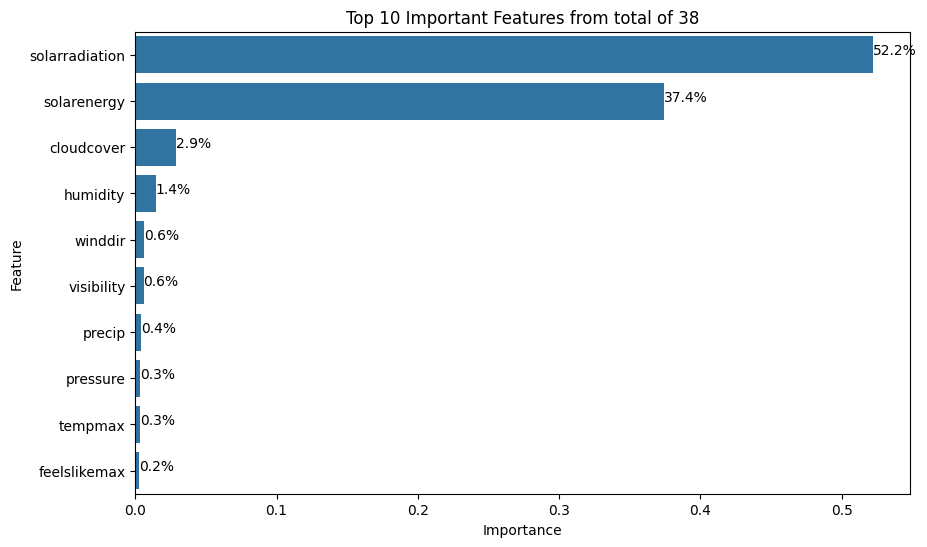

In [24]:
# sorting of most important features
importances = initial_model_rf.feature_importances_
importances_df = pd.DataFrame({'Feature': X_train_enc.columns, 'Importance': importances})
plt.figure(figsize=(10, 6))
importances_df = importances_df.sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=importances_df.head(10))

# data labels
for index, value in enumerate(importances_df['Importance'].head(10)):
    plt.text(value, index, f'{value*100:.1f}%')

plt.title(f'Top 10 Important Features from total of {len(importances_df)}')
plt.show()

Text(0.5, 1.0, 'True vs Predicted Values')

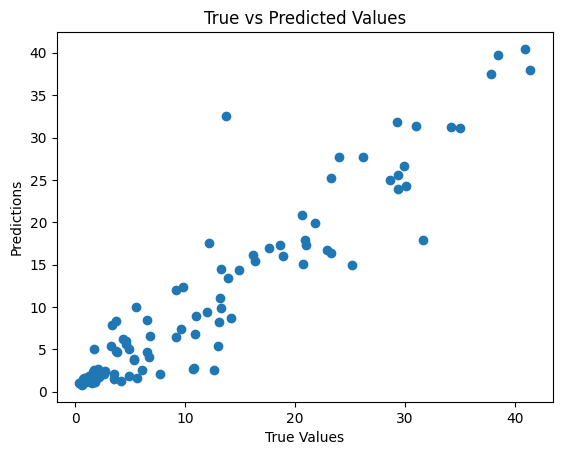

In [25]:
plt.scatter(y_val, y_val_pred)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')

### 4.1.2 Optuna optimalization

In [ ]:
def objective(trial):
    params_random = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 1500, step=10),
        "max_depth": trial.suggest_int("max_depth", 40, 80),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0) if trial.suggest_categorical("bootstrap", [True, False]) else None,
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.1),
        "min_weight_fraction_leaf": trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5),
        "warm_start": trial.suggest_categorical("warm_start", [False, True])
    }

   
    if not params_random["bootstrap"]:
        params_random["max_samples"] = None
    
    model = RandomForestRegressor(**params_random, random_state=42,n_jobs=-1)   
    model.fit(X_train_enc, y_train)
    
    y_val_pred = model.predict(X_val_enc)
    rmse = root_mean_squared_error(y_val, y_val_pred)
    
    return rmse

In [52]:
start = time.time()
rf_model_study = optuna.create_study(direction="minimize")
rf_model_study.optimize(objective, n_trials=300)
end = time.time()
print(f"Optimization completed in {end - start:.2f} seconds")

[I 2025-07-12 17:29:02,965] A new study created in memory with name: no-name-43d8b1ff-ba5e-4a5c-84d0-c1c07fb82bdb
[I 2025-07-12 17:29:03,805] Trial 0 finished with value: 7.303962684614783 and parameters: {'n_estimators': 730, 'max_depth': 48, 'min_samples_split': 11, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'bootstrap': True, 'max_samples': 0.7410599909379494, 'ccp_alpha': 0.047788509573070674, 'min_weight_fraction_leaf': 0.418502327943143, 'warm_start': True}. Best is trial 0 with value: 7.303962684614783.
[I 2025-07-12 17:29:04,328] Trial 1 finished with value: 4.639162304504685 and parameters: {'n_estimators': 640, 'max_depth': 31, 'min_samples_split': 19, 'min_samples_leaf': 13, 'max_features': 'sqrt', 'bootstrap': False, 'ccp_alpha': 0.0917394080449504, 'min_weight_fraction_leaf': 0.026674808326075217, 'warm_start': False}. Best is trial 1 with value: 4.639162304504685.
[I 2025-07-12 17:29:05,612] Trial 2 finished with value: 5.169622765804326 and parameters: {'n_estimator

Optimization completed in 309.49 seconds


In [48]:
optuna_rf_best_params = rf_model_study.best_params
optuna_rf_best_params

{'n_estimators': 1160,
 'max_depth': 48,
 'min_samples_split': 17,
 'min_samples_leaf': 8,
 'max_features': None,
 'bootstrap': True,
 'max_samples': 0.5258097307323075,
 'ccp_alpha': 0.012989612728941984,
 'min_weight_fraction_leaf': 0.017646181073481634,
 'warm_start': False}

In [53]:
optuna.visualization.plot_optimization_history(rf_model_study)


In [54]:
optuna.visualization.plot_parallel_coordinate(rf_model_study)
